# FAMA-FRENCH 3 FACTOR MODEL

### This set of Python code replicates the Fama French risk factors SMB and HML, in addition to the excess market risk factor. It utilizes CRSP data for pricing related items and Compustat data for fundamental data. 

* Qingyi (Freda) Song Drechsler's code on Momentum  
* based on CRSP and Compustat, and Fama and French (1993) Momentum Portfolio 
* https://www.fredasongdrechsler.com/data-crunching/fama-french
* version: 2022-Jul-02

Note: the program may take a while to run, as retrieving data from WRDS is really time-consuming.

In [1]:
# Import Python packages and establish connection with WRDS server 

import pandas as pd
import numpy as np
import datetime as dt
import wrds
#import psycopg2 
import matplotlib.pyplot as plt
from dateutil.relativedelta import *
from pandas.tseries.offsets import *
from scipy import stats
pd.options.mode.chained_assignment = None  # default='warn'

###################
# Connect to WRDS #;  it will prompt fpr enter user name and password 
###################
conn = wrds.Connection()

Enter your WRDS username [taizhiwu]:sssp42
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
Loading library list...
Done


`conn = wrds.Connection()`:
1. It creates an object called conn.
2. It will firstly prompt us to enter the name and password so that we can use it
3. After authorizing, we can enter sql commands to get data we want

Note: If wrds is not installed, use `pip install wrds`

### Part 1: Use Compustat XpressFeed (annual data) as the source of historical accounting data in order to calculate the value of Book Equity.

In [2]:
# Extract data fundamental information from Compustat, and calculate book-value of equities.

###################
# Compustat Block #
###################
comp = conn.raw_sql("""
                    select gvkey, datadate, at, pstkl, txditc,
                    pstkrv, seq, pstk
                    from comp.funda
                    where indfmt='INDL' 
                    and datafmt='STD'
                    and popsrc='D'
                    and consol='C'
                    and datadate >= '01/01/1959'
                    """, date_cols=['datadate'])

#### Compustat XpressFeed Variables:   
* GVKEY   = Global Company Key
* AT      = Total Assets                                              
* PSTKL   = Preferred Stock Liquidating Value                         
* TXDITC  = Deferred Taxes and Investment Tax Credit                  
* PSTKRV  = Preferred Stock Redemption Value                          
* SEQ     = Total Parent Stockholders' Equity                         
* PSTK    = Preferred/Preference Stock (Capital) - Total 

#### Retrieving Data
1. We enter sql commands to get data we want.
2. First argument should be a SQL command and the command should be quotted by """ """ sign.
3. The argument named date_cols is used to specify the date column

#### Basic SQL syntax
SQL command should be composited with several clauses and every clause should start with a key word. We analyse the command line by line:
1. SELECT gvkey, datadate, at, pstkl, txditc, pstkrv, seq, pstk
select columns named 'gvkey', 'datadate', 'at', 'pstkl', 'txditc', 'pstkrv', 'seq', 'pstk'.

2. FROM comp.funda
select these columns from table named 'comp.funda'.

3. WHERE indfmt = 'INDL' and datafmt='STD' and popsrc='D' and consol='C' and datadate >= '01/01/1959'
This clause refers to filtering conditions. There can be many conditions and you can connect them with keyword AND/OR/NOT.
Therefore, this clause means that we only select the rows which fullfill the following conditions at the same time.

In [3]:
comp['year'] = comp['datadate'].dt.year

1. `.dt.year` is a method to get year property from a datetimelike pandas column
e.g. '2001-02-03' should become '2001' after using this method.

2. There're many other methods like this to deal with datetimelike pandas column:
    .dt.second: get second;
    .dt.hour: get hour;
    .dt.quarter: get quarter.

3. More information: https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html

In [4]:
# create preferred stock
comp['ps'] = np.where(comp['pstkrv'].isnull(), comp['pstkl'], comp['pstkrv'])
comp['ps'] = np.where(comp['ps'].isnull(), comp['pstk'], comp['ps'])
comp['ps'] = np.where(comp['ps'].isnull(), 0, comp['ps'])
comp['txditc'] = comp['txditc'].fillna(0)

# create book equity
comp['be'] = comp['seq'] + comp['txditc'] - comp['ps']
comp['be'] = np.where(comp['be'] > 0, comp['be'], np.nan)

# number of years in Compustat
comp = comp.sort_values(by = ['gvkey','datadate'])
comp['count'] = comp.groupby(['gvkey']).cumcount()

comp = comp[['gvkey','datadate','year','be','count']]
comp.head()

,gvkey,datadate,year,be,count
0,001000,1961-12-31,1961,NaN,0
1,001000,1962-12-31,1962,NaN,1
2,001000,1963-12-31,1963,0.561,2
3,001000,1964-12-31,1964,0.627,3
4,001000,1965-12-31,1965,0.491,4


`np.where(condition, x, y, ...)`
* functions in numpy package to return elements in x if condition is true, y elsewhere;
* `np.where(comp['pstkrv'].isnull(), comp['pstkl'], comp['pstkrv'])`: for each row in the dataframe, return `comp['pstkl']` if `comp['pstkrv']` is null and `comp['pstkrv']` otherwise;
* `comp['ps'] = np.where(comp['ps'].isnull(), comp['pstk'], comp['ps'])`: for 'ps' column, replace null values with `comp['pstk']`;
* `comp['ps'] = np.where(comp['ps'].isnull() ,0, comp['ps'])`: for 'ps' column, replace null values with 0;
* The first three lines create preferred stock column without null values.

`.isnull()`
* returns a Bool type column, with True if the corresponding index is null value and False otherwise.

`.fillna(input number)`
* used on pd.Series to fill null value with input number.

`.groupby()`
* used to split the data into groups based on some criteria.

#### Columns
`comp['count']`: the order for each gvkey.

`comp['be']`: book equity value.

### Part 2: Extract price and shares outstanding information from CRSP for calculating market value of equity.

In [5]:
###################
# CRSP Block      #
###################
# sql similar to crspmerge macro
crsp_m = conn.raw_sql("""
                      select a.permno, a.permco, a.date, b.shrcd, b.exchcd,
                      a.ret, a.retx, a.shrout, a.prc
                      from crsp.msf as a
                      left join crsp.msenames as b
                      on a.permno=b.permno
                      and b.namedt<=a.date
                      and a.date<=b.nameendt
                      where a.date between '01/01/1959' and '12/31/2017'
                      and b.exchcd between 1 and 3
                      """, date_cols=['date']) 

#### CRSP MSF Table Variables
* permno = unique stock level identifier
* permco = unique permanent company identifier assigned by CRSP
* ret = holding period return
* retx = holding period return without dividends
* shrout = number of shares outstanding
* prc = price

#### CRSP MSENames Table Variables
* permno = unique stock level identifier
* shrcd = share code
* exchcd = exchange code

In [6]:
# change variable format to int
crsp_m[['permco','permno','shrcd','exchcd']] = crsp_m[['permco','permno','shrcd','exchcd']].astype(int)

`.astype(type)`
* convert the type for the following use.

In [7]:
# Line up date to be end of month
crsp_m['jdate'] = crsp_m['date'] + MonthEnd(0)

`MonthEnd()`
* a function in pandas.tseries.offsets that can be added with pandas columns;
* can use integer as input, e.g use 0 here. If n is the input, it will move to the end of next n month. (0 means move to the end to this month).

In [8]:
# add delisting return
dlret = conn.raw_sql("""
                     select permno, dlret, dlstdt 
                     from crsp.msedelist
                     """, date_cols=['dlstdt'])

dlret.permno = dlret.permno.astype(int)
#dlret['dlstdt']=pd.to_datetime(dlret['dlstdt'])
dlret['jdate'] = dlret['dlstdt'] + MonthEnd(0)

In [9]:
crsp = pd.merge(crsp_m, dlret, how='left', on=['permno','jdate'])
crsp['dlret'] = crsp['dlret'].fillna(0)
crsp['ret'] = crsp['ret'].fillna(0)

`pd.merge(a, b, how=, on=)`
* function in pandas to merge DataFrames;
* first 2 arguments should be the DataFrames to be merged;
* `how=`: specify the merge rule. e.g 'left' here means that the rows will be shown in new DataFrame if is not in b but shownn in a;
* `on=`: specify the key column to merge;
* We use `.fillna()` method after merging because this is a left merging (if there're row that are not shown in b, there will be null value). Specifically, we use `.fillna(0)` method to replace null values with 0.

In [10]:
# retadj factors in the delisting returns
crsp['retadj'] = (1 + crsp['ret']) * (1 + crsp['dlret']) - 1

# calculate market equity
crsp['me'] = crsp['prc'].abs() * crsp['shrout'] 
crsp = crsp.drop(['dlret','dlstdt','prc','shrout'], axis=1)
crsp = crsp.sort_values(by=['jdate','permco','me'])

`.drop(columns=, axis=)`
* used to drop columns or rows in DataFrame;
* axis argument is used to specify the first argument we input is row names or column names.

`.sort_values(by=)`
* specify columns to sort the DataFrame.

`crsp['me'] = crsp['prc'].abs() * crsp['shrout']`: market value of equity = price * shares outstanding

### Part 3: As market cap is calculated at issue-level (permno), and book value of equity is calculated at company level, we need to aggregate market cap at company level (permco) for later book-to-market value calculation. Market cap of companies at December of year t-1 is used for portfolio formation at June of year t.

In [11]:
### Aggregate Market Cap ###
# sum of me across different permno belonging to same permco a given date
crsp_summe = crsp.groupby(['jdate','permco'])['me'].sum().reset_index()

# largest mktcap within a permco/date
crsp_maxme = crsp.groupby(['jdate','permco'])['me'].max().reset_index()

`DataFrame.groupby()`
* group rows by some certain columns;
* can further apply aggregate function. e.g. `.groupby().sum()` here. It will fisrtly sum the rows in each group, stack them together, and finally return it.

`.reset_index()`
* usually used when filtering DataFrame;
* when we get subset of DataFrame, the index is usually reserved, for example, if we get a subset of 1st, 3rd, 5th rows, the new DataFrame still has original index(1,3,5). If we want them to be 0, 1, 2, `.reset_index()` should be applied to reset the index.

In [12]:
# join by jdate/maxme to find the permno
crsp1 = pd.merge(crsp, crsp_maxme, how='inner', on=['jdate','permco','me'])

# drop me column and replace with the sum me
crsp1 = crsp1.drop(['me'], axis=1)

# join with sum of me to get the correct market cap info
crsp2 = pd.merge(crsp1, crsp_summe, how='inner', on=['jdate','permco'])

# sort by permno and date and also drop duplicates
crsp2 = crsp2.sort_values(by=['permno','jdate']).drop_duplicates()

# keep December market cap
crsp2['year'] = crsp2['jdate'].dt.year
crsp2['month'] = crsp2['jdate'].dt.month
decme = crsp2[crsp2['month']==12]
decme = decme[['permno','date','jdate','me','year']].rename(columns={'me':'dec_me'})

### July to June dates
crsp2['ffdate'] = crsp2['jdate'] + MonthEnd(-6)
crsp2['ffyear'] = crsp2['ffdate'].dt.year
crsp2['ffmonth'] = crsp2['ffdate'].dt.month
crsp2['1+retx'] = 1 + crsp2['retx']
crsp2 = crsp2.sort_values(by=['permno','date'])

`.drop_duplicates()`
* return DataFrame with duplicate rows removed.

`df[df==...]`, `df[df!=...]`, etc.
* usually a good way to filter the dataframe; e.g. `crsp2[crsp2['month']==12]`: select the December data.

As mentioned above, 
* in `crsp1=pd.merge(crsp, crsp_maxme, how='inner', on=['jdate','permco','me'])`, how='inner', it means that resulting DataFrame only include rows that are shown in both crsp and crsp_maxme;
* `.dt.year`: get year number;
* `.dt.month`: get month number;
* `MonthEnd(-6)`: means move to the end of 6 months earlier.

At the end of this block, dataframe `crsp2` contains
* permno, permco: identifier
* date, shrcd (share code), exchcd (exchange code)
* ret: holding period return
* retx: holding period return without dividends
* retadj: adjusted return (computed as `crsp['retadj'] = (1 + crsp['ret']) * (1 + crsp['dlret']) - 1`)
* jdate (ffdate + 6 month), ffdate (fama-french factor date)
* me: market value of equity

In [13]:
crsp2.head()

,permno,permco,date,shrcd,exchcd,ret,retx,jdate,retadj,me,year,month,ffdate,ffyear,ffmonth,1+retx
1176178,10000,7952,1986-01-31,10,3,0.000000,NaN,1986-01-31,0.000000,16100.000000,1986,1,1985-07-31,1985,7,NaN
1182380,10000,7952,1986-02-28,10,3,-0.257143,-0.257143,1986-02-28,-0.257143,11960.000000,1986,2,1985-08-31,1985,8,0.742857
1188591,10000,7952,1986-03-31,10,3,0.365385,0.365385,1986-03-31,0.365385,16330.000000,1986,3,1985-09-30,1985,9,1.365385
1194812,10000,7952,1986-04-30,10,3,-0.098592,-0.098592,1986-04-30,-0.098592,15172.000000,1986,4,1985-10-31,1985,10,0.901408
1201043,10000,7952,1986-05-30,10,3,-0.222656,-0.222656,1986-05-31,-0.222656,11793.859375,1986,5,1985-11-30,1985,11,0.777344


In [14]:
# cumret by stock
crsp2['cumretx'] = crsp2.groupby(['permno','ffyear'])['1+retx'].cumprod()

# lag cumret
crsp2['lcumretx'] = crsp2.groupby(['permno'])['cumretx'].shift(1)

# lag market cap
crsp2['lme'] = crsp2.groupby(['permno'])['me'].shift(1)

# if first permno then use me/(1+retx) to replace the missing value
crsp2['count'] = crsp2.groupby(['permno']).cumcount()
crsp2['lme'] = np.where(crsp2['count']==0, crsp2['me']/crsp2['1+retx'], crsp2['lme'])

# baseline me
mebase = crsp2[crsp2['ffmonth']==1][['permno', 'ffyear', 'lme']].rename(columns={'lme': 'mebase'})

# merge result back together
crsp3 = pd.merge(crsp2, mebase, how='left', on=['permno','ffyear'])
crsp3['wt'] = np.where(crsp3['ffmonth']==1, crsp3['lme'], crsp3['mebase']*crsp3['lcumretx'])

decme['year'] = decme['year'] + 1
decme = decme[['permno','year','dec_me']]

# Info as of June
crsp3_jun = crsp3[crsp3['month']==6]

crsp_jun = pd.merge(crsp3_jun, decme, how='inner', on=['permno','year'])
crsp_jun = crsp_jun[['permno', 'date', 'jdate', 'shrcd', 'exchcd', 'retadj', 'me', 'wt', 'cumretx', 'mebase', 'lme', 'dec_me']]
crsp_jun = crsp_jun.sort_values(by=['permno','jdate']).drop_duplicates()

At the end of this block, dataframe `crsp_jun` contains:
* date, jdate: jdate == date;
* retadj: adjusted return;
* me: market value of equity;
* lme: lag market cap (date - 1 month);
* cumretx: cumulative holding period of return without dividends within the year;
* mebase: market value of equity baseline, calculated as `crsp2['me']/crsp2['1+retx']`;
* wt: maret value of equity calculated as `crsp3['mebase']*crsp3['lcumretx']` for each month, later will be used as weight for each firm;
* dec_me: market value of equity in the last December.

In [15]:
crsp_jun

,permno,date,jdate,shrcd,exchcd,retadj,me,wt,cumretx,mebase,lme,dec_me
0,10001,1987-06-30,1987-06-30,11,3,0.051429,5.822125e+03,5.602187e+03,0.959184,6.033125e+03,5.636312e+03,6.937000e+03
1,10001,1988-06-30,1988-06-30,11,3,-0.012039,6.200000e+03,6.379563e+03,1.063830,5.822125e+03,6.386000e+03,5.828000e+03
2,10001,1989-06-30,1989-06-30,11,3,0.017143,7.007000e+03,6.944000e+03,1.120000,6.200000e+03,6.986000e+03,6.362250e+03
3,10001,1990-06-29,1990-06-30,11,3,0.014103,1.005225e+04,9.759750e+03,1.392857,7.007000e+03,1.001325e+04,1.034775e+04
4,10001,1991-06-28,1991-06-30,11,3,0.078481,1.126650e+04,1.018112e+04,1.076923,1.005225e+04,1.040825e+04,1.001300e+04
...,...,...,...,...,...,...,...,...,...,...,...,...
299677,93436,2013-06-28,2013-06-30,11,3,0.098200,1.303672e+07,1.029638e+07,3.431128,3.295557e+06,1.129646e+07,3.868428e+06
299678,93436,2014-06-30,2014-06-30,11,3,0.155412,2.990859e+07,2.522951e+07,2.236028,1.303672e+07,2.578218e+07,1.851646e+07
299679,93436,2015-06-30,2015-06-30,11,3,0.069617,3.409612e+07,3.124667e+07,1.117471,2.990859e+07,3.170212e+07,2.795427e+07
299680,93436,2016-06-30,2016-06-30,11,3,-0.049053,3.142062e+07,2.837276e+07,0.791322,3.409612e+07,3.293602e+07,3.154331e+07


### Some aggregate functions
`.cumprod()`
* return cumulative product;
* e.g when we use cumprod for [2, 4, 3], we will get [2, 8, 24];
* in `crsp2['cumretx'] = crsp2.groupby(['permno','ffyear'])['1+retx'].cumprod()`, this method is used to get the cumulative statistics.

`.shift()`
* return previous value;
* e.g.

df:

|    | object | period | value|
|---:|:-------|:-------|:-----|
|0   |    1   |    1   |  24|
|1   |    1    |   2   |  67|
|2   |    1    |   4   |  89|
|3   |    2    |   4  |    5|
|4   |    2    |  23  |   23|

`df['prev_value'] = df.groupby('object')['value'].shift()`:

|    |object  |period | value | prev_value|
|---:|:-------|:-------|:-----|:----|
|0    |   1   |    1   |  24  |     NaN|
|1   |    1   |    2   |  67  |    24.0|
|2    |   1   |    4   |  89   |   67.0|
|3    |   2   |    4   |   5  |     NaN|
|4    |   2   |   23   |  23 |      5.0|

`.cumcount()`
* reset the index in each group starting from 0;
* e.g.

df:

|   |A|
|-:|:-|
|0 | a|
|1|  a|
|2 | a|
|3 | b|
|4 | b|
|5 | a|

`df.groupby('A').cumcount()`:

| |A|
|-:|:-|
|0 |   0|
|1 |   1|
|2  |  2|
|3 |   0|
|4  |  1|
|5 |   3|

### Part 4: Extract linking information from CRSP CCM table to join the market cap information from CRSP together with book-value of equity information from Compustat. With the joined data frame, book-to-market is a straightforward ratio calculation.




In [16]:
#######################
# CCM Block           #
#######################
ccm = conn.raw_sql("""
                  select gvkey, lpermno as permno, linktype, linkprim, 
                  linkdt, linkenddt
                  from crsp.ccmxpf_linktable
                  where substr(linktype,1,1)='L'
                  and (linkprim ='C' or linkprim='P')
                  """, date_cols=['linkdt', 'linkenddt'])

# if linkenddt is missing then set to today date
ccm['linkenddt'] = ccm['linkenddt'].fillna(pd.to_datetime('today'))

ccm1 = pd.merge(comp[['gvkey','datadate','be', 'count']], ccm, how='left', on=['gvkey'])
ccm1['yearend'] = ccm1['datadate'] + YearEnd(0)
ccm1['jdate'] = ccm1['yearend'] + MonthEnd(6)

# set link date bounds
ccm2 = ccm1[(ccm1['jdate']>=ccm1['linkdt']) & (ccm1['jdate']<=ccm1['linkenddt'])]
ccm2 = ccm2[['gvkey','permno','datadate','yearend', 'jdate','be', 'count']]

# link comp and crsp
ccm_jun = pd.merge(crsp_jun, ccm2, how='inner', on=['permno', 'jdate'])
ccm_jun['beme'] = ccm_jun['be'] * 1000 / ccm_jun['dec_me']

The block adds `be` (book-value equity) and `beme` (book-to-market ratio) to dataframe `crsp_jun`

In [17]:
ccm_jun

,permno,date,jdate,shrcd,exchcd,retadj,me,wt,cumretx,mebase,lme,dec_me,gvkey,datadate,yearend,be,count,beme
0,10001,1987-06-30,1987-06-30,11,3,0.051429,5.822125e+03,5.602187e+03,0.959184,6.033125e+03,5.636312e+03,6.937000e+03,012994,1986-06-30,1986-12-31,7.037,0,1.014415
1,10001,1988-06-30,1988-06-30,11,3,-0.012039,6.200000e+03,6.379563e+03,1.063830,5.822125e+03,6.386000e+03,5.828000e+03,012994,1987-06-30,1987-12-31,7.038,1,1.207618
2,10001,1989-06-30,1989-06-30,11,3,0.017143,7.007000e+03,6.944000e+03,1.120000,6.200000e+03,6.986000e+03,6.362250e+03,012994,1988-06-30,1988-12-31,7.286,2,1.145192
3,10001,1990-06-29,1990-06-30,11,3,0.014103,1.005225e+04,9.759750e+03,1.392857,7.007000e+03,1.001325e+04,1.034775e+04,012994,1989-06-30,1989-12-31,8.466,3,0.818149
4,10001,1991-06-28,1991-06-30,11,3,0.078481,1.126650e+04,1.018112e+04,1.076923,1.005225e+04,1.040825e+04,1.001300e+04,012994,1990-06-30,1990-12-31,9.438,4,0.942575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277468,93436,2013-06-28,2013-06-30,11,3,0.098200,1.303672e+07,1.029638e+07,3.431128,3.295557e+06,1.129646e+07,3.868428e+06,184996,2012-12-31,2012-12-31,124.700,4,0.032235
277469,93436,2014-06-30,2014-06-30,11,3,0.155412,2.990859e+07,2.522951e+07,2.236028,1.303672e+07,2.578218e+07,1.851646e+07,184996,2013-12-31,2013-12-31,673.941,5,0.036397
277470,93436,2015-06-30,2015-06-30,11,3,0.069617,3.409612e+07,3.124667e+07,1.117471,2.990859e+07,3.170212e+07,2.795427e+07,184996,2014-12-31,2014-12-31,969.906,6,0.034696
277471,93436,2016-06-30,2016-06-30,11,3,-0.049053,3.142062e+07,2.837276e+07,0.791322,3.409612e+07,3.293602e+07,3.154331e+07,184996,2015-12-31,2015-12-31,1130.989,7,0.035855


### Part 5: Sorting portfolios and creating Fama French 3 factors (actually 2 that needed to be formed here): SML and HML

In [18]:
# Following the original paper's methodology, 
# NYSE stock universe is used for portfolio formation based on size. 

# select NYSE stocks for bucket breakdown
# exchcd = 1 and positive beme and positive me and shrcd in (10,11) and at least 2 years in comp
nyse = ccm_jun[(ccm_jun['exchcd']==1) & (ccm_jun['beme']>0) & (ccm_jun['me']>0) & \
             (ccm_jun['count']>=1) & ((ccm_jun['shrcd']==10) | (ccm_jun['shrcd']==11))]

# size breakdown
nyse_sz = nyse.groupby(['jdate'])['me'].median().to_frame().reset_index().rename(columns={'me':'sizemedn'})

# beme breakdown
nyse_bm = nyse.groupby(['jdate'])['beme'].describe(percentiles=[0.3, 0.7]).reset_index()
nyse_bm = nyse_bm[['jdate','30%','70%']].rename(columns={'30%':'bm30', '70%':'bm70'})

nyse_breaks = pd.merge(nyse_sz, nyse_bm, how='inner', on=['jdate'])

# join back size and beme breakdown
ccm1_jun = pd.merge(ccm_jun, nyse_breaks, how='left', on=['jdate'])

`.rename(columns={})`
* We can input a dict into the columns argument;
* the key of the dict is original column name;
* the value of the dict is the changed column name.

Here we create dataframe `ccm1_jun`
* Column `bm30` and `bm70` are the thresholds of book-to-market value, and will be further used to form HML factor;
* Column `sizemedn` is the median of the size of firms, and will be used to form SMB factor.

In [19]:
ccm1_jun

,permno,date,jdate,shrcd,exchcd,retadj,me,wt,cumretx,mebase,...,dec_me,gvkey,datadate,yearend,be,count,beme,sizemedn,bm30,bm70
0,10001,1987-06-30,1987-06-30,11,3,0.051429,5.822125e+03,5.602187e+03,0.959184,6.033125e+03,...,6.937000e+03,012994,1986-06-30,1986-12-31,7.037,0,1.014415,5.416934e+05,0.523197,0.946923
1,10001,1988-06-30,1988-06-30,11,3,-0.012039,6.200000e+03,6.379563e+03,1.063830,5.822125e+03,...,5.828000e+03,012994,1987-06-30,1987-12-31,7.038,1,1.207618,4.962825e+05,0.616384,1.118397
2,10001,1989-06-30,1989-06-30,11,3,0.017143,7.007000e+03,6.944000e+03,1.120000,6.200000e+03,...,6.362250e+03,012994,1988-06-30,1988-12-31,7.286,2,1.145192,5.600411e+05,0.574145,1.007378
3,10001,1990-06-29,1990-06-30,11,3,0.014103,1.005225e+04,9.759750e+03,1.392857,7.007000e+03,...,1.034775e+04,012994,1989-06-30,1989-12-31,8.466,3,0.818149,5.549456e+05,0.490988,0.935675
4,10001,1991-06-28,1991-06-30,11,3,0.078481,1.126650e+04,1.018112e+04,1.076923,1.005225e+04,...,1.001300e+04,012994,1990-06-30,1990-12-31,9.438,4,0.942575,5.401538e+05,0.621579,1.215534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277468,93436,2013-06-28,2013-06-30,11,3,0.098200,1.303672e+07,1.029638e+07,3.431128,3.295557e+06,...,3.868428e+06,184996,2012-12-31,2012-12-31,124.700,4,0.032235,2.524758e+06,0.414010,0.857750
277469,93436,2014-06-30,2014-06-30,11,3,0.155412,2.990859e+07,2.522951e+07,2.236028,1.303672e+07,...,1.851646e+07,184996,2013-12-31,2013-12-31,673.941,5,0.036397,3.075006e+06,0.321435,0.682947
277470,93436,2015-06-30,2015-06-30,11,3,0.069617,3.409612e+07,3.124667e+07,1.117471,2.990859e+07,...,2.795427e+07,184996,2014-12-31,2014-12-31,969.906,6,0.034696,2.835649e+06,0.309958,0.715478
277471,93436,2016-06-30,2016-06-30,11,3,-0.049053,3.142062e+07,2.837276e+07,0.791322,3.409612e+07,...,3.154331e+07,184996,2015-12-31,2015-12-31,1130.989,7,0.035855,2.570064e+06,0.338715,0.810665


In [20]:
# Functions to assign stocks into size and book-to-market portfolios:

# function to assign sz and bm bucket
def sz_bucket(row):
    if row['me'] == np.nan:
        value = ''
    elif row['me'] <= row['sizemedn']:
        value = 'S'
    else:
        value = 'B'
    return value

def bm_bucket(row):
    if 0 <= row['beme'] <= row['bm30']:
        value = 'L'
    elif row['beme'] <= row['bm70']:
        value = 'M'
    elif row['beme'] > row['bm70']:
        value = 'H'
    else:
        value = ''
    return value

# Then apply the functions to the dataframe:

# assign size portfolio
ccm1_jun['szport'] = np.where((ccm1_jun['beme']>0) & (ccm1_jun['me']>0) & (ccm1_jun['count']>=1), ccm1_jun.apply(sz_bucket, axis=1), '')

# assign book-to-market portfolio
ccm1_jun['bmport'] = np.where((ccm1_jun['beme']>0) & (ccm1_jun['me']>0) & (ccm1_jun['count']>=1), ccm1_jun.apply(bm_bucket, axis=1), '')

# create positivebmeme and nonmissport variable
ccm1_jun['posbm'] = np.where((ccm1_jun['beme']>0) & (ccm1_jun['me']>0) & (ccm1_jun['count']>=1), 1, 0)
ccm1_jun['nonmissport'] = np.where((ccm1_jun['bmport']!=''), 1, 0)

# store portfolio assignment as of June
june = ccm1_jun[['permno','date', 'jdate', 'bmport','szport','posbm','nonmissport']]
june['ffyear'] = june['jdate'].dt.year

# merge back with monthly records
crsp3 = crsp3[['date','permno','shrcd','exchcd','retadj','me','wt','cumretx','ffyear','jdate']]
ccm3 = pd.merge(crsp3, 
        june[['permno','ffyear','szport','bmport','posbm','nonmissport']], how='left', on=['permno','ffyear'])

# keeping only records that meet the criteria
ccm4 = ccm3[(ccm3['wt']>0) & (ccm3['posbm']==1) & (ccm3['nonmissport']==1) & 
          ((ccm3['shrcd']==10) | (ccm3['shrcd']==11))]

`.apply()`
* Apply a function along an axis of the DataFrame;
* e.g. in `.apply(bm_bucket, axis=1)`, it applies function `bm_bucket()` (which is defined above) to each column of the DataFrame.

* We firstly created two functions `sz_bucket` and `bm_bucket`;
* then we label each row with `S` (small size), `B` (big size) under column `szport`;
* and `H` (high book-to-market value), `M` (medium book-to-market value), and `L` (low book-to-market value) under column `bmport`.

In [21]:
ccm4

,date,permno,shrcd,exchcd,retadj,me,wt,cumretx,ffyear,jdate,szport,bmport,posbm,nonmissport
47,1988-07-29,10001,11,3,0.030000,6.386000e+03,6.200000e+03,1.030000,1988,1988-07-31,S,H,1.0,1.0
48,1988-08-31,10001,11,3,0.029126,6.572000e+03,6.386000e+03,1.060000,1988,1988-08-31,S,H,1.0,1.0
49,1988-09-30,10001,11,3,-0.021132,6.362250e+03,6.572000e+03,1.020000,1988,1988-09-30,S,H,1.0,1.0
50,1988-10-31,10001,11,3,0.039216,6.611750e+03,6.324000e+03,1.060000,1988,1988-10-31,S,H,1.0,1.0
51,1988-11-30,10001,11,3,0.000000,6.611750e+03,6.572000e+03,1.060000,1988,1988-11-30,S,H,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3777100,2017-08-31,93436,11,3,0.100257,5.939508e+07,5.397517e+07,0.984210,2017,2017-08-31,B,L,1.0,1.0
3777101,2017-09-29,93436,11,3,-0.041585,5.731060e+07,5.938654e+07,0.943281,2017,2017-09-30,B,L,1.0,1.0
3777102,2017-10-31,93436,11,3,-0.028056,5.571925e+07,5.691697e+07,0.916816,2017,2017-10-31,B,L,1.0,1.0
3777103,2017-11-30,93436,11,3,-0.068410,5.190749e+07,5.532009e+07,0.854097,2017,2017-11-30,B,L,1.0,1.0


In [22]:
############################
# Form Fama French Factors #
############################

# function to calculate value weighted return
def wavg(group, avg_name, weight_name):
    d = group[avg_name]
    w = group[weight_name]
    try:
        return (d * w).sum() / w.sum()
    except ZeroDivisionError:
        return np.nan
    
# Apply the function to calculate value weighted returns within each portfolio:

# value-weigthed return
vwret = ccm4.groupby(['jdate','szport','bmport']).apply(wavg, 'retadj','wt').to_frame().reset_index().rename(columns={0: 'vwret'})
vwret['sbport'] = vwret['szport'] + vwret['bmport']

# firm count
vwret_n = ccm4.groupby(['jdate','szport','bmport'])['retadj'].count().reset_index().rename(columns={'retadj':'n_firms'})
vwret_n['sbport'] = vwret_n['szport'] + vwret_n['bmport']

# transpose
ff_factors = vwret.pivot(index='jdate', columns='sbport', values='vwret').reset_index()
ff_nfirms = vwret_n.pivot(index='jdate', columns='sbport', values='n_firms').reset_index()

# create SMB and HML factors
ff_factors['WH'] = (ff_factors['BH'] + ff_factors['SH']) / 2
ff_factors['WL'] = (ff_factors['BL'] + ff_factors['SL']) / 2
ff_factors['WHML'] = ff_factors['WH'] - ff_factors['WL']

ff_factors['WB'] = (ff_factors['BL'] + ff_factors['BM'] + ff_factors['BH']) / 3
ff_factors['WS'] = (ff_factors['SL'] + ff_factors['SM'] + ff_factors['SH']) / 3
ff_factors['WSMB'] = ff_factors['WS'] - ff_factors['WB']
ff_factors = ff_factors.rename(columns={'jdate':'date'})

# n firm count
ff_nfirms['H'] = ff_nfirms['SH'] + ff_nfirms['BH']
ff_nfirms['L'] = ff_nfirms['SL'] + ff_nfirms['BL']
ff_nfirms['HML'] = ff_nfirms['H'] + ff_nfirms['L']

ff_nfirms['B'] = ff_nfirms['BL'] + ff_nfirms['BM'] + ff_nfirms['BH']
ff_nfirms['S'] = ff_nfirms['SL'] + ff_nfirms['SM'] + ff_nfirms['SH']
ff_nfirms['SMB'] = ff_nfirms['B'] + ff_nfirms['S']
ff_nfirms['TOTAL'] = ff_nfirms['SMB']
ff_nfirms = ff_nfirms.rename(columns={'jdate':'date'})

`.pivot(index=None, columns=None, values=None)`
* return reshaped DataFrame organized by given index / column values;

As below, dataframe `ff_factors` contains constructed factors. Specifically,
* `WHML` (weighted high minus low) equals `WH` (weighted high) minus `WL` (weighted low);
* `WSMB` (weighted small minus big) equals 

In [23]:
ff_factors

sbport,date,BH,BL,BM,SH,SL,SM,WH,WL,WHML,WB,WS,WSMB
0,1961-07-31,NaN,0.017327,0.045662,0.000000,NaN,-0.022321,NaN,NaN,NaN,NaN,NaN,NaN
1,1961-08-31,NaN,0.021898,0.126638,0.119565,NaN,0.091324,NaN,NaN,NaN,NaN,NaN,NaN
2,1961-09-30,NaN,0.024061,0.015504,-0.048544,NaN,-0.004202,NaN,NaN,NaN,NaN,NaN,NaN
3,1961-10-31,NaN,0.004684,0.069231,-0.102041,NaN,-0.067511,NaN,NaN,NaN,NaN,NaN,NaN
4,1961-11-30,NaN,0.072261,0.028777,0.125000,NaN,0.018100,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,2017-08-31,-0.007356,0.014416,-0.007012,-0.022540,-0.003952,-0.023719,-0.014948,0.005232,-0.020180,0.000016,-0.016737,-0.016753
674,2017-09-30,0.034841,0.011947,0.037514,0.076555,0.050447,0.082341,0.055698,0.031197,0.024501,0.028101,0.069781,0.041681
675,2017-10-31,0.015554,0.032309,0.016413,0.010607,0.005463,0.004664,0.013080,0.018886,-0.005805,0.021425,0.006911,-0.014514
676,2017-11-30,0.032374,0.029942,0.041417,0.029901,0.039337,0.023260,0.031138,0.034639,-0.003502,0.034578,0.030832,-0.003746


In [24]:
# One might be interested in comparing the program generated Fama French factors
# with the actual ones reported by Fama French: 

###################
# Compare With FF #
###################
_ff = conn.get_table(library='ff', table='factors_monthly')
_ff = _ff[['date','smb','hml']]
_ff['date'] = _ff['date'] + MonthEnd(0)

_ffcomp = pd.merge(_ff, ff_factors[['date','WSMB','WHML']], how='inner', on=['date'])
_ffcomp70 = _ffcomp[_ffcomp['date']>='01/01/1970']
print(stats.pearsonr(_ffcomp70['smb'], _ffcomp70['WSMB']))
print(stats.pearsonr(_ffcomp70['hml'], _ffcomp70['WHML']))

(0.9959347155821368, 0.0)
(0.9821803335953425, 0.0)


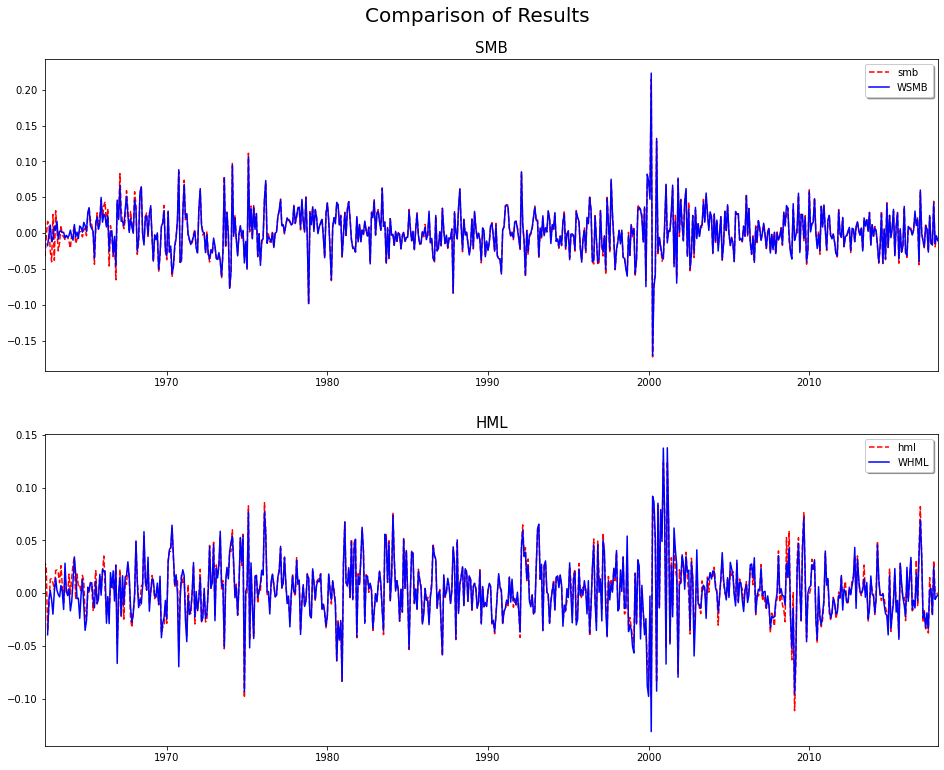

In [25]:
# Last but not least, the chart below illustrates the how the output
# of this Python program lines up against the Fama French 3-factors. 
# Solid blue line represents the risk  factor generated from the Python code, and 
# dash red line represents the original data series from Fama French library. 

_ffcomp.date = pd.to_datetime(_ffcomp.date)
_ffcomp.set_index('date', inplace=True)
_ffcomp.head(2)

plt.figure(figsize=(16,12))
plt.suptitle('Comparison of Results', fontsize=20)

ax1 = plt.subplot(211)
ax1.set_title('SMB', fontsize=15)
ax1.set_xlim([dt.datetime(1962,6,1), dt.datetime(2017,12,31)])
ax1.plot(_ffcomp['smb'], 'r--', _ffcomp['WSMB'], 'b-')
ax1.legend(('smb','WSMB'), loc='upper right', shadow=True)

ax2 = plt.subplot(212)
ax2.set_title('HML', fontsize=15)
ax2.plot(_ffcomp['hml'], 'r--', _ffcomp['WHML'], 'b-')
ax2.set_xlim([dt.datetime(1962,6,1), dt.datetime(2017,12,31)])
ax2.legend(('hml','WHML'), loc='upper right', shadow=True)

plt.subplots_adjust(top=0.92, hspace=0.2)

plt.show()

### Basic Syntax of matplotlib
1. Use `plt.figure(figsize=())` to specify the size of figure.

2. `ax1 = plt.subplot(211)`: specifies the subplot; it is actually an abbreviation of `ax1 = plt.subplot(2, 1, 1)`

    2 means total number of subplot rows is 2;

    1 means total number of subplot column is 1;

    1 means the subplot we are plotting is the 1st subplot. Consequently, when we plot the second subplot, we use `ax2 = plt.subplot(212)`.

3. `ax1.set_title('SMB', fontsize=15)`:

    First argument is the content of title;

    Fontsize argument means the size of the title.

4. `ax1.set_xlim([dt.datetime(1962,6,1), dt.datetime(2017,12,31)])`

    Set the x axis. Here we set the x axis range from 1962.6.1 to 2017.12.31.

5. `ax1.plot(_ffcomp['smb'], 'r--', _ffcomp['WSMB'], 'b-')`

    This is where we plot the graph;
    
    The code is actually `ax1.plot(data1, linestyle1, data2, linestyle2)`;

    `linestyle` has 2 components: color and style of line. Character means color, e.g r -> red, b -> blue; after that is the style of line, e.g - means solid line, -- means dashed line;

    Here, we plot 2 graphs, one is `_ffcomp['smb']` in green dashed line, the other is `_ffcomp['WSMB']` in blue solid line.
    

6. `ax1.legend(('smb','WSMB'), loc='upper right', shadow=True)`

    Set the legend;

    The first argument sets the variable that needs a legend;

    `loc`: set the location of the legend;

    `shadow`: set whether to use shadow with the legend.

7. `plt.subplots_adjust(top=0.92, hspace=0.2)`

    Adjust the subplot layout parameters;

    `top`: set the position of the top edge of the subplot, as a fraction of the figure height

    `hspace`: set the height of the padding between subplots, as a fraction of the average Axes height.


8. `plt.show()`

    Show the plot we drawed, we usually use this command at the end.